In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [7]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [8]:
df.shape

(32581, 12)

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [10]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

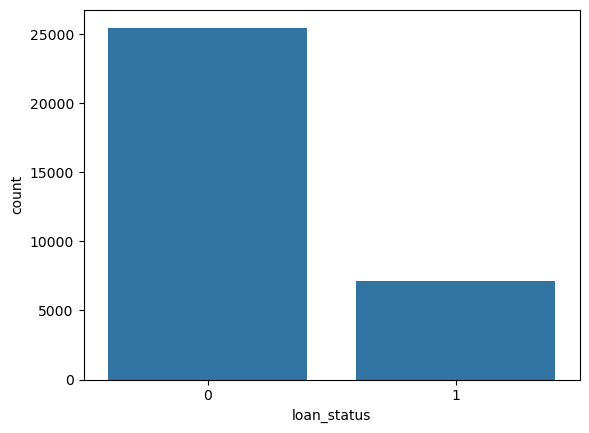

In [12]:
sns.countplot(x='loan_status', data=df)

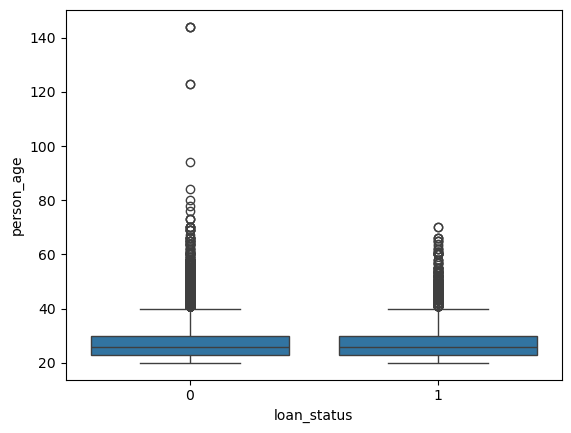

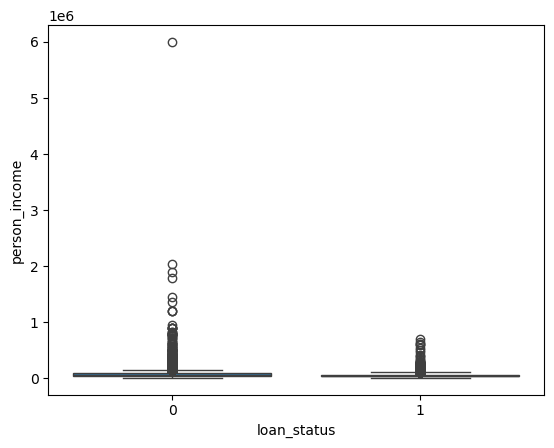

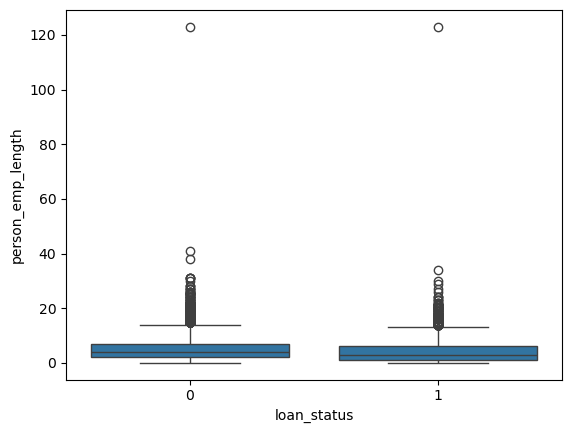

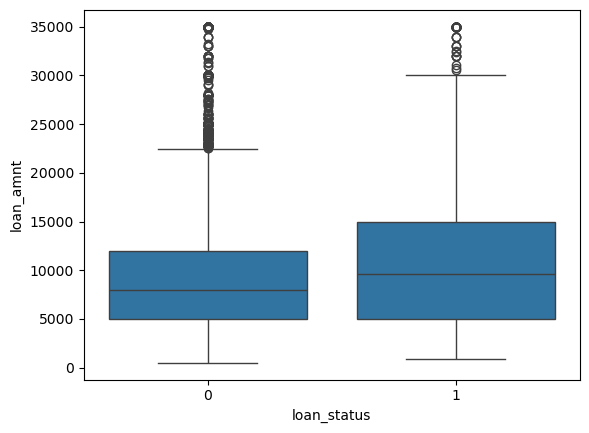

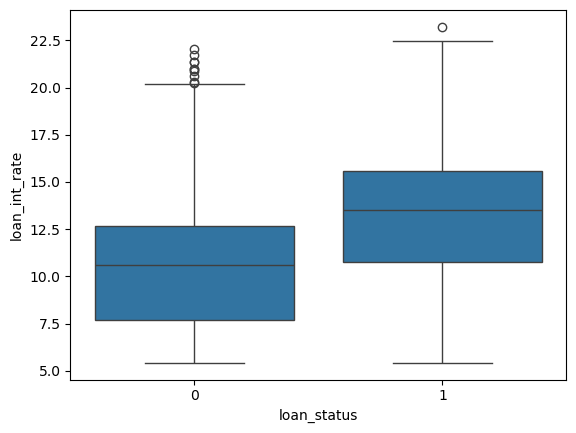

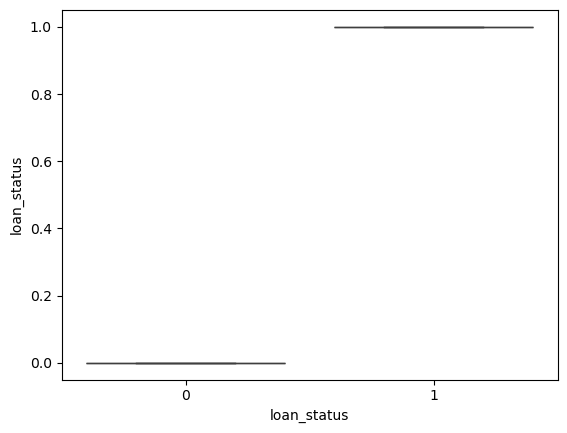

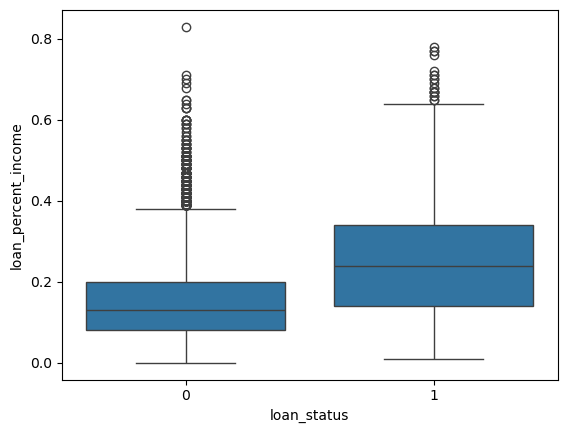

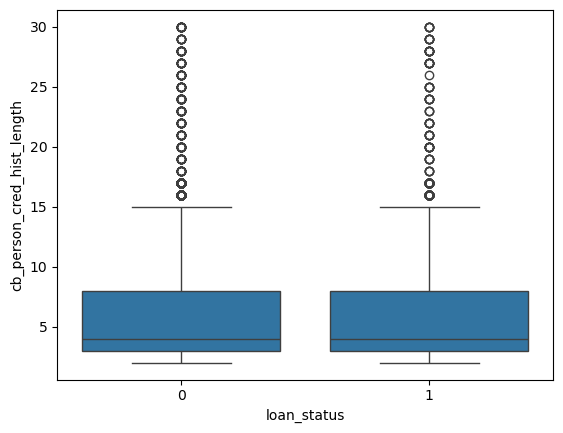

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
for i in numerical_cols:
    sns.boxplot(x='loan_status', y=i, data=df)
    plt.show()

    

In [13]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: >

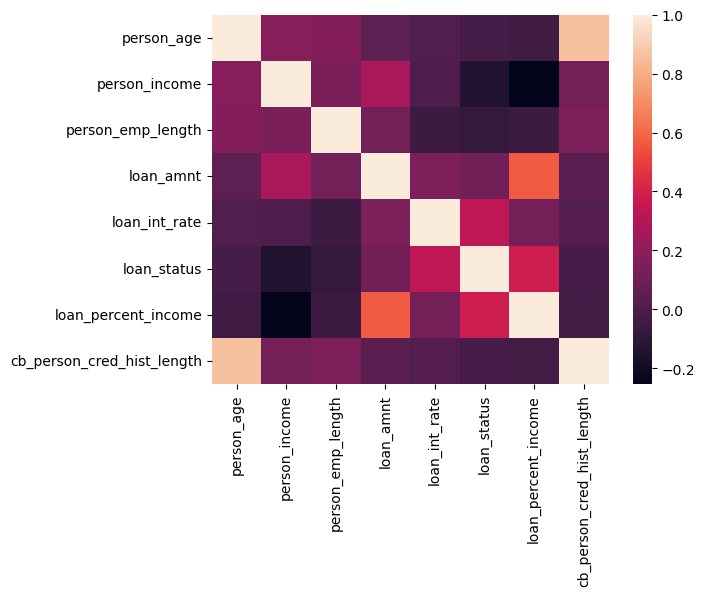

In [24]:
sns.heatmap(df.corr(numeric_only=True))

In [27]:
df_copy = df.copy()
df_copy.drop_duplicates(inplace=True)

In [36]:
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]

df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

df_copy = df_copy[df_copy['loan_amnt'] > 0]

In [37]:
X = df_copy.drop('loan_status', axis=1)
Y = df_copy['loan_status']

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [72]:
numeric_cols = ['person_age', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_income' ]
categorical_cols = ['person_home_ownership',  'loan_intent', 'cb_person_default_on_file']

In [73]:
neg , pos = np.bincount(Y_train)
scale_weights = neg/pos

In [74]:
scale_weights


np.float64(3.6312213039485766)

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())]), numeric_cols),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                                ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
    ])

In [76]:
preprocessor_xg = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_cols),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                                ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
    ])

In [77]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [78]:
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([('preprocessor', preprocessor_lr),
                           ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight ="balanced"))])
lr_cv_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([('preprocessor', preprocessor_xg),
          ('classifier', XGBClassifier(n_estimators=300,max_depth=5, learning_rate=0.1,
                                        random_state=42, scale_pos_weight=scale_weights))])

In [89]:
from sklearn.model_selection import cross_validate

for cv_name, pipe in [('LogisticRegression', lr_cv_pipeline), ('XGBoost', xgb_cv_pipeline)]:
    cv_results =cross_validate(pipe, X_train, Y_train, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1)

    print(cv_name)
    print(f"ROC-AUC:{cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy:{cv_results['test_accuracy'].mean()}")
    print(f"Precision:{cv_results['test_precision'].mean()}")
    print(f"Recall:{cv_results['test_recall'].mean()}")
    print(f"F1:{cv_results['test_f1'].mean()}")

LogisticRegression
ROC-AUC:0.8499208626236461
Accuracy:0.7704320795166327
Precision:0.4804081129180475
Recall:0.7682277318640954
F1:0.5910836669402715
XGBoost
ROC-AUC:0.9388884776993237
Accuracy:0.9035968309335904
Precision:0.7702444585842011
Recall:0.7891643709825529
F1:0.7794773500270605


In [94]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('Preprocessor',preprocessor_lr),
    ('Classifier',LogisticRegression(class_weight ="balanced"))
])
baseline_model.fit(X_train, Y_train)

,steps,"[('Preprocessor', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
#We have to evaluate logistic model and xgboost model on the basis of their metrics.
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
def evaluate_model(model_name,model, X_test, Y_test,threshold = None):
    Y_pred = model.predict()
    Y_pred_prob = model.predict_proba(X_test)[:,1]

    #metrics 
    accuracy = accuracy_score(Y_test, Y_pred) #overall model's performance
    precision = precision_score(Y_test, Y_pred) #of the ones i predicted as positive, how many were actually right
    recall = recall_score(Y_test, Y_pred) #of the ones that were actually positive, how many did i predict as positive
    f1 = f1_score(Y_test, Y_pred) #harmonic mean of precision and recall
    roc_auc = roc_auc_score(Y_test, Y_pred_prob) #area under the ROC curve

    #confusion matrix
    cm = confusion_matrix(Y_test, Y_pred)
    class_report = classification_report(Y_test, Y_pred)

    print (f"accuracy: {accuracy:.2f}")
    print (f"precision: {precision:.2f}")
    print (f"recall: {recall:.2f}")
    print (f"f1: {f1:.2f}")
    print (f"roc_auc: {roc_auc:.2f}")

    #Plotting confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    #Plotting ROC AUC curve
    from sklearn.metrics import roc_curve, auc
    precission, recall, thresholds = prescision_recall_curve(Y_test, Y_pred_prob)
    plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {model_name}')
    plt.show()

In [96]:
xg_model = Pipeline([('Preprocessor',preprocessor_xg),
    ('Classifier',XGBClassifier(n_estimators=300,max_depth=5, learning_rate=0.1,
                                        random_state=42, scale_pos_weight=scale_weights))])
xg_model.fit(X_train, Y_train)

,steps,"[('Preprocessor', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
#Evaluate the logistic model

